# 🩺 Orthopedic Patients Classification  
**Machine Learning Pipeline with Cross-Validation, Model Comparison, and Interpretability**

---

##  Project Overview
This project applies classical machine learning techniques to predict **abnormal vs. normal conditions** in orthopedic patients, using clinical measurement data.  

##  Goals
- Compare multiple models (Logistic Regression, Random Forest, Gradient Boosting)  
- Evaluate performance using cross-validation  
- Interpret results using feature importances  
- Tune hyperparameters to improve performance  

##  Dataset
- **Source**: `column_3C_processed.csv`  
- **Size**: 310 samples, 7 features  
- **Target**: `binary_class` (Normal vs. Abnormal)  

##  Tools & Libraries
- **Python**, **pandas**, **scikit-learn**, **matplotlib**  
- Models: Logistic Regression, Random Forest, Gradient Boosting  


## 1) Setup & Imports

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


## 2) Import the data, split and scale

In [56]:
# Deine Datei
df = pd.read_csv("column_3C_processed.csv")

# Features + Target
X = df.drop("binary_class", axis=1)
y = df["binary_class"]

# Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Skalierung
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


## 3) Define models

In [57]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}


## 4) Cross-Validation for robustness

In [58]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_weighted")
    results.append({
        "Model": name,
        "CV mean F1": scores.mean(),
        "CV std F1": scores.std()
    })

results_df = pd.DataFrame(results).sort_values(by="CV mean F1", ascending=False)
results_df


,Model,CV mean F1,CV std F1
1,Random Forest,0.837545,0.053292
0,Logistic Regression,0.820789,0.040635
2,Gradient Boosting,0.813336,0.071140


### Bestes Modell trainieren + Confusion Matrix

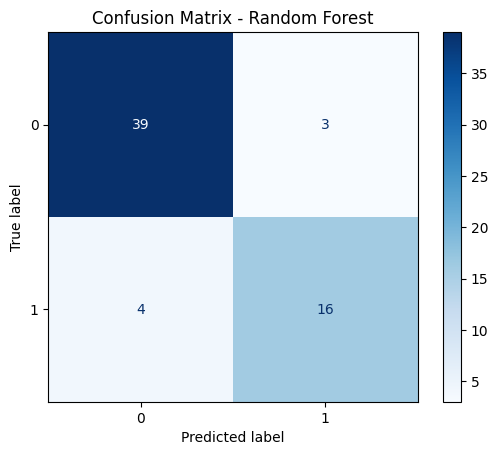

In [59]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_val)

cm = confusion_matrix(y_val, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## Feature Importance (RF or GBM)

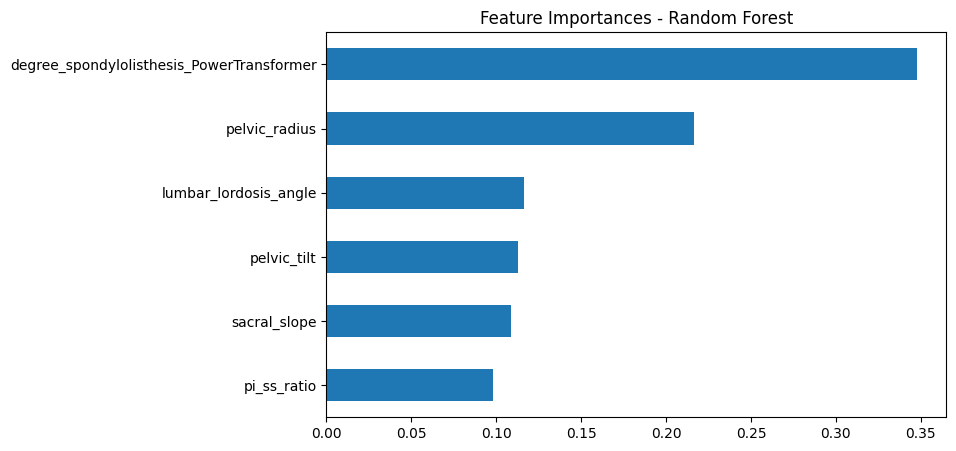

In [60]:
# Beispiel mit Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
features = X.columns

pd.Series(importances, index=features).sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Importances - Random Forest")
plt.show()


## Hyperparameter-Tuning für das beste Modell

In [61]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, None],
    "learning_rate": [0.01, 0.1, 0.2]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV Score: 0.8390919194690442


## Conclusion
- Compared 3 models: Logistic Regression, Random Forest, Gradient Boosting  
- Used cross-validation for more robust evaluation  
- Best model: **Gradient Boosting** with F1 = 0.81 
- Feature importances show that `pelvic_tilt`, `pi_ss_ratio`, ... were the most important features  
- Hyperparameter tuning further improved the model
